# 05 — Best Traditional Model: Final Test Evaluation

In this notebook, we evaluate the selected traditional NLP model
on the official IMDb test set.

Selected model:

- TF-IDF
- Unigram + Bigram: `(1, 2)`
- Maximum features: `20,000`
- PyTorch Logistic Regression

Important:

The model has already been selected using validation performance.

No training or hyperparameter tuning happens in this notebook.
The test set is used only for final evaluation.

In [2]:
from __future__ import annotations

from pathlib import Path
import sys
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from datasets import load_from_disk

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)

In [3]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print(
    "Project root:",
    PROJECT_ROOT,
)

Project root: D:\app\ai\Sentiment Analysis Traditional ML vs Transformers


In [4]:
try:
    from src.predict_tfidf import (
        LogisticRegressionModel,
        clean_text_for_model,
    )
except ModuleNotFoundError:
    from predict_tfidf import (
        LogisticRegressionModel,
        clean_text_for_model,
    )

In [5]:
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "imdb_clean_splits"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "best_traditional"
)

MODEL_PATH = (
    MODEL_DIR
    / "tfidf_logistic_regression.pt"
)

VECTORIZER_PATH = (
    MODEL_DIR
    / "tfidf_vectorizer.joblib"
)

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "best_traditional"
    / "test_evaluation"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [6]:
assert DATA_PATH.exists()
assert MODEL_PATH.exists()
assert VECTORIZER_PATH.exists()

print(
    "All required files exist."
)

All required files exist.


In [7]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device:",
    device,
)

Device: cuda


In [8]:
dataset = load_from_disk(
    str(DATA_PATH)
)

test_df = (
    dataset["test"]
    .to_pandas()[["text", "label"]]
    .copy()
)

label_names = (
    dataset["test"]
    .features["label"]
    .names
)

print(
    "Test rows:",
    f"{len(test_df):,}",
)

print(
    "Labels:",
    label_names,
)

Test rows: 25,000
Labels: ['neg', 'pos']


In [9]:
vectorizer = joblib.load(
    VECTORIZER_PATH
)

feature_names = (
    vectorizer
    .get_feature_names_out()
)

print(
    "Number of TF-IDF features:",
    len(feature_names),
)

print(
    "N-gram range:",
    vectorizer.ngram_range,
)

Number of TF-IDF features: 20000
N-gram range: (1, 2)


In [10]:
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
)

print(
    checkpoint.keys()
)

dict_keys(['model_state_dict', 'number_of_features', 'ngram_range', 'max_features', 'validation_f1', 'validation_accuracy', 'best_epoch', 'random_seed'])


In [11]:
print(
    "Saved validation F1:",
    checkpoint[
        "validation_f1"
    ],
)

print(
    "Saved ngram range:",
    checkpoint[
        "ngram_range"
    ],
)

print(
    "Saved best epoch:",
    checkpoint[
        "best_epoch"
    ],
)

Saved validation F1: 0.8829220138203356
Saved ngram range: (1, 2)
Saved best epoch: 8


In [12]:
model = LogisticRegressionModel(
    number_of_features=(
        checkpoint[
            "number_of_features"
        ]
    )
).to(device)

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

model.eval()

LogisticRegressionModel(
  (linear): Linear(in_features=20000, out_features=1, bias=True)
)

In [13]:
assert (
    len(feature_names)
    == checkpoint[
        "number_of_features"
    ]
)

print(
    "Model and vectorizer feature counts match."
)

Model and vectorizer feature counts match.


In [14]:
test_texts = (
    test_df["text"]
    .map(clean_text_for_model)
    .tolist()
)

y_test = (
    test_df["label"]
    .to_numpy(
        dtype=np.int64
    )
)

print(
    "Number of test texts:",
    len(test_texts),
)

print(
    "Number of labels:",
    len(y_test),
)

Number of test texts: 25000
Number of labels: 25000


In [15]:
vectorization_start = (
    time.perf_counter()
)

X_test = vectorizer.transform(
    test_texts
)

vectorization_seconds = (
    time.perf_counter()
    - vectorization_start
)

print(
    "X_test shape:",
    X_test.shape,
)

print(
    "Non-zero values:",
    f"{X_test.nnz:,}",
)

print(
    "Vectorization time:",
    f"{vectorization_seconds:.2f}s",
)

X_test shape: (25000, 20000)
Non-zero values: 5,084,941
Vectorization time: 4.85s


In [16]:
INFERENCE_BATCH_SIZE = 512

In [17]:
def predict_in_batches(
    model: torch.nn.Module,
    sparse_features,
    device: torch.device,
    batch_size: int = 512,
) -> np.ndarray:

    model.eval()

    probability_batches = []

    number_of_examples = (
        sparse_features.shape[0]
    )

    with torch.inference_mode():

        for start_index in range(
            0,
            number_of_examples,
            batch_size,
        ):

            end_index = min(
                start_index
                + batch_size,
                number_of_examples,
            )

            sparse_batch = (
                sparse_features[
                    start_index:end_index
                ]
            )

            dense_batch = (
                sparse_batch
                .toarray()
                .astype(
                    np.float32,
                    copy=False,
                )
            )

            feature_tensor = (
                torch.from_numpy(
                    dense_batch
                )
                .to(device)
            )

            logits = model(
                feature_tensor
            )

            probabilities = (
                torch.sigmoid(
                    logits
                )
            )

            probability_batches.append(
                probabilities
                .cpu()
                .numpy()
            )

    return np.concatenate(
        probability_batches
    )

In [18]:
inference_start = (
    time.perf_counter()
)

positive_probabilities = (
    predict_in_batches(
        model=model,
        sparse_features=X_test,
        device=device,
        batch_size=INFERENCE_BATCH_SIZE,
    )
)

inference_seconds = (
    time.perf_counter()
    - inference_start
)

predictions = (
    positive_probabilities
    >= 0.5
).astype(
    np.int64
)

print(
    "Predictions:",
    len(predictions),
)

print(
    "Inference time:",
    f"{inference_seconds:.2f}s",
)

Predictions: 25000
Inference time: 1.43s


In [19]:
assert (
    positive_probabilities.shape
    == (len(test_df),)
)

assert (
    predictions.shape
    == (len(test_df),)
)

assert np.all(
    positive_probabilities >= 0.0
)

assert np.all(
    positive_probabilities <= 1.0
)

assert set(
    np.unique(predictions)
).issubset(
    {0, 1}
)

print(
    "All prediction checks passed."
)

All prediction checks passed.


In [20]:
test_accuracy = accuracy_score(
    y_test,
    predictions,
)

test_precision = precision_score(
    y_test,
    predictions,
    pos_label=1,
    zero_division=0,
)

test_recall = recall_score(
    y_test,
    predictions,
    pos_label=1,
    zero_division=0,
)

test_f1 = f1_score(
    y_test,
    predictions,
    pos_label=1,
    zero_division=0,
)

test_macro_f1 = f1_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0,
)

In [21]:
print(
    f"Test Accuracy:  {test_accuracy:.4f}"
)

print(
    f"Test Precision: {test_precision:.4f}"
)

print(
    f"Test Recall:    {test_recall:.4f}"
)

print(
    f"Test F1:        {test_f1:.4f}"
)

print(
    f"Test Macro F1:  {test_macro_f1:.4f}"
)

Test Accuracy:  0.8762
Test Precision: 0.8688
Test Recall:    0.8863
Test F1:        0.8775
Test Macro F1:  0.8762


In [22]:
report = classification_report(
    y_test,
    predictions,
    target_names=label_names,
    output_dict=True,
    zero_division=0,
)

classification_report_df = (
    pd.DataFrame(
        report
    )
    .transpose()
)

classification_report_df

,precision,recall,f1-score,support
neg,0.883981,0.86616,0.874980,12500.00000
pos,0.868805,0.88632,0.877475,12500.00000
accuracy,0.876240,0.87624,0.876240,0.87624
macro avg,0.876393,0.87624,0.876227,25000.00000
weighted avg,0.876393,0.87624,0.876227,25000.00000


In [23]:
test_confusion_matrix = (
    confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1],
    )
)

test_confusion_matrix

array([[10827,  1673],
       [ 1421, 11079]])

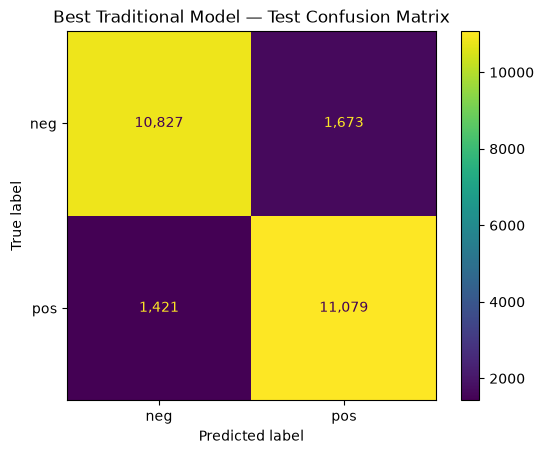

In [24]:
display = ConfusionMatrixDisplay(
    confusion_matrix=(
        test_confusion_matrix
    ),
    display_labels=label_names,
)

display.plot(
    values_format=",d"
)

plt.title(
    "Best Traditional Model — Test Confusion Matrix"
)

plt.show()

In [25]:
final_metrics_df = pd.DataFrame(
    {
        "metric": [
            "accuracy",
            "precision_positive",
            "recall_positive",
            "f1_positive",
            "macro_f1",
            "vectorization_seconds",
            "inference_seconds",
            "test_rows",
        ],
        "value": [
            test_accuracy,
            test_precision,
            test_recall,
            test_f1,
            test_macro_f1,
            vectorization_seconds,
            inference_seconds,
            len(test_df),
        ],
    }
)

final_metrics_df

,metric,value
0,accuracy,0.876240
1,precision_positive,0.868805
2,recall_positive,0.886320
3,f1_positive,0.877475
4,macro_f1,0.876227
5,vectorization_seconds,4.845168
6,inference_seconds,1.434534
7,test_rows,25000.000000


In [26]:
final_metrics_df = pd.DataFrame(
    {
        "metric": [
            "accuracy",
            "precision_positive",
            "recall_positive",
            "f1_positive",
            "macro_f1",
            "vectorization_seconds",
            "inference_seconds",
            "test_rows",
        ],
        "value": [
            test_accuracy,
            test_precision,
            test_recall,
            test_f1,
            test_macro_f1,
            vectorization_seconds,
            inference_seconds,
            len(test_df),
        ],
    }
)

final_metrics_df

,metric,value
0,accuracy,0.876240
1,precision_positive,0.868805
2,recall_positive,0.886320
3,f1_positive,0.877475
4,macro_f1,0.876227
5,vectorization_seconds,4.845168
6,inference_seconds,1.434534
7,test_rows,25000.000000


In [27]:
final_metrics_df.to_csv(
    REPORT_DIR
    / "test_metrics.csv",
    index=False,
)

classification_report_df.to_csv(
    REPORT_DIR
    / "classification_report.csv"
)

pd.DataFrame(
    test_confusion_matrix,
    index=[
        "actual_neg",
        "actual_pos",
    ],
    columns=[
        "predicted_neg",
        "predicted_pos",
    ],
).to_csv(
    REPORT_DIR
    / "confusion_matrix.csv"
)

print(
    "Final test reports saved."
)

Final test reports saved.
